In [1]:
import neurokit2 as nk
import wfdb
import pandas as pd
import numpy as np
import glob
import os
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- 1. Upgraded Feature Extraction ---
def extract_features_v2(record_path, label):
    try:
        rec = wfdb.rdrecord(record_path)
        fs = rec.fs
        
        # Parse demographics from header comments
        age = np.nan
        sex = 0 # 0 for Male, 1 for Female (numeric for ML)
        for comment in rec.comments:
            if 'Age' in comment:
                try:
                    age_str = comment.split(':')[1].strip()
                    age = float(age_str) if age_str.isnumeric() else np.nan
                except: pass
            if 'Sex' in comment:
                sex_str = comment.split(':')[1].strip().lower()
                if 'f' in sex_str: sex = 1
                
        # Clean signal and find peaks
        clean_signal = nk.ecg_clean(rec.p_signal[:, 1], sampling_rate=fs)
        _, rpeaks = nk.ecg_peaks(clean_signal, sampling_rate=fs)
        hrv_metrics = nk.hrv(rpeaks, sampling_rate=fs)
        
        mean_rr = hrv_metrics['HRV_MeanNN'].values[0] if 'HRV_MeanNN' in hrv_metrics else np.nan
        sdnn = hrv_metrics['HRV_SDNN'].values[0] if 'HRV_SDNN' in hrv_metrics else np.nan
        
        # Approximate QRS Duration
        _, waves = nk.ecg_delineate(clean_signal, rpeaks, sampling_rate=fs, method="dwt")
        valid_widths = [(off - on) / fs * 1000 for on, off in zip(waves['ECG_R_Onsets'], waves['ECG_R_Offsets']) if not np.isnan(on) and not np.isnan(off)]
        avg_qrs = np.nanmean(valid_widths) if valid_widths else np.nan

        # Extract Patient ID from the filename (e.g., '100726') to prevent data leakage later
        patient_id = os.path.basename(record_path).split('_')[0] 

        return {
            'Patient_ID': patient_id,
            'Age': age,
            'Sex': sex,
            'Mean_RR_ms': mean_rr,
            'SDNN_ms': sdnn,
            'QRS_Duration_ms': avg_qrs,
            'Label': label
        }
    except Exception as e:
        return None

# --- 2. Process Expanded Dataset ---
sami_records = sorted([f.replace('.hea', '') for f in glob.glob('samitrop_wfdb/**/*.hea', recursive=True)])
ptb_records = sorted([f.replace('.hea', '') for f in glob.glob('ptbxl_wfdb/**/*.hea', recursive=True)])

print("Extracting features... (This will take a few minutes)")
all_data = [extract_features_v2(p, 1) for p in sami_records[:1600]] + [extract_features_v2(p, 0) for p in ptb_records[:500]]
df = pd.DataFrame([d for d in all_data if d is not None]).dropna()
df.to_csv('ecg_features_expanded.csv', index=False)
print(f"Extraction complete! Saved {len(df)} records.")

Extracting features... (This will take a few minutes)
Extraction complete! Saved 2043 records.


--- Model Evaluation ---
Logistic Regression Challenge Score (Top 5% TPR): 0.063
Random Forest Challenge Score (Top 5% TPR): 0.060


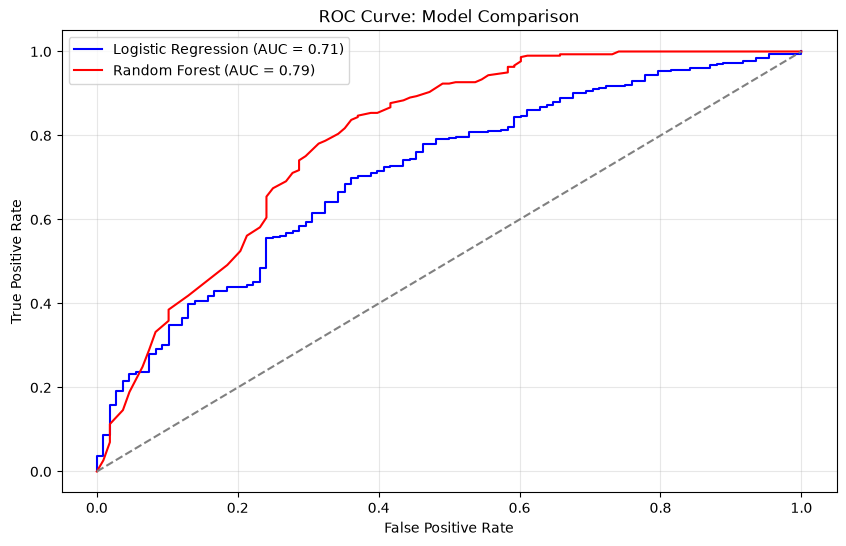

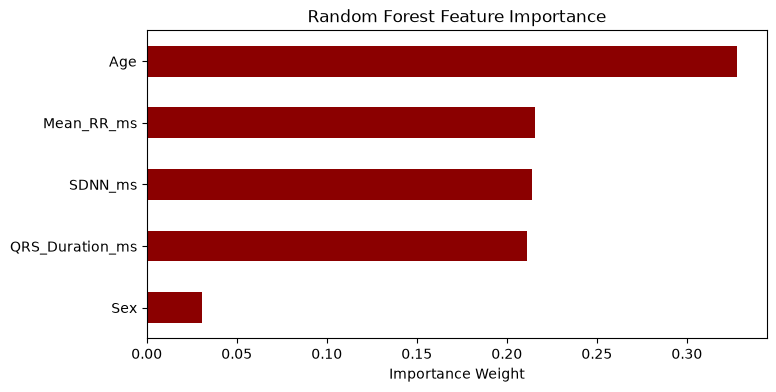

In [2]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

df = pd.read_csv('ecg_features_expanded.csv')

# --- 3. Define Features and Splitting ---
# We exclude Patient_ID and Label from our training features
X = df[['Age', 'Sex', 'Mean_RR_ms', 'SDNN_ms', 'QRS_Duration_ms']]
y = df['Label']
groups = df['Patient_ID']

# GroupShuffleSplit ensures the same patient doesn't end up in both Train and Test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# --- 4. Train Models ---
# Model 1: Logistic Regression (The simple baseline)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Model 2: Random Forest (The complex baseline)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# --- 5. The Custom Challenge Scoring Metric ---
def calculate_challenge_score(y_true, y_pred_proba):
    # Sort patients by predicted risk (highest probability first)
    results = pd.DataFrame({'True_Label': y_true, 'Risk_Score': y_pred_proba})
    results = results.sort_values(by='Risk_Score', ascending=False)
    
    # Take the top 5% highest-risk predictions
    top_5_percent_count = max(1, int(len(results) * 0.05))
    top_5_patients = results.head(top_5_percent_count)
    
    # Calculate how many of those top 5% were ACTUALLY true positives
    true_positives_in_top = top_5_patients['True_Label'].sum()
    total_true_positives = results['True_Label'].sum()
    
    # Return the True Positive Rate of the top 5%
    return true_positives_in_top / total_true_positives if total_true_positives > 0 else 0

# Get predictions
lr_probs = log_reg.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

print("--- Model Evaluation ---")
print(f"Logistic Regression Challenge Score (Top 5% TPR): {calculate_challenge_score(y_test, lr_probs):.3f}")
print(f"Random Forest Challenge Score (Top 5% TPR): {calculate_challenge_score(y_test, rf_probs):.3f}")

# --- 6. Visualizing the ROC Curve ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.2f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.2f})', color='red')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve: Model Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 7. Feature Importance (Random Forest) ---
importances = rf.feature_importances_
plt.figure(figsize=(8, 4))
pd.Series(importances, index=X.columns).sort_values(ascending=True).plot(kind='barh', color='darkred')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Weight')
plt.show()

In [5]:
import pandas as pd
# Import the official evaluation script
import evaluate_model 

# 1. Save your true labels and your model's predictions to a CSV file 
results_df = pd.DataFrame({
    'Patient_ID': X_test.index, 
    'True_Label': y_test,
    'Predicted_Probability': rf_probs # <-- Changed to rf_probs
})
results_df.to_csv('my_predictions.csv', index=False)

# 2. Run the official evaluation function 
try:
    official_score = evaluate_model.evaluate('my_predictions.csv')
    print(f"Official Challenge Score: {official_score}")
except AttributeError:
    print("Check inside evaluate_model.py to see what the main grading function is named!")

Check inside evaluate_model.py to see what the main grading function is named!
